# CMB Lensing and quadratic estimator tutorial 
_Louis Legrand, with some help from Julien Carron and Sebastian Belkner_


This tutorial is an introduction to a CMB lensing reconstruction pipeline. We will learn how to make lensed simulations of the CMB and how to run a quadratic estimator on these maps to get an estimate of the lensing potential field. 

A general lensing reconstruction pipeline can be summarized as below (image credits A.Lewis):

![flow](img/flow.png)

Here we will play a bit with **healpy** to generate CMB maps and we will use **lenspyx** to lens them. We will use **plancklens** to run a QE and estimate the CMB lensing potential. From there we will estimate the lensing spectrum, it's normalization and the see how we can debias it.


In [1]:
%matplotlib inline

import os
import healpy as hp
import numpy as np
from os.path import join as opj

# import lenspyx
import plancklens
from plancklens import utils
from plancklens import qest, qresp
from plancklens import nhl
from plancklens.n1 import n1
from plancklens.helpers.cachers import cacher_npy

from matplotlib import pyplot as plt
import matplotlib as mpl

import copy
from scipy.interpolate import interp1d


In [2]:
# Maplotlib settings

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['font.size'] = 20
mpl.rcParams['figure.figsize'] = 8.5, 5.5

# mpl.rcParams['mathtext.fontset'] = 'cm'
# mpl.rcParams['mathtext.rm'] = 'serif'
# mpl.rc('text', usetex=True)
mpl.rcParams['errorbar.capsize'] = 4
mpl.rc('legend', fontsize=15)

In [3]:
# Useful functions for plotting spectra

def f(ell):
    """To plot l(l+1)/2pi CMB spectra """
    return ell*(ell+1)/2/np.pi

def pp2kk(ell):
    """Convert Cl^{\phi, \phi} into Cl^{\kappa, \kappa}"""
    return (ell*(ell+1))**2/4



In [4]:
nside = 2048 # The lensed tlm's are computed with healpy map2alm from a lensed map at resolution 'nside_lens'

# 1 - Preliminary settings 

In [5]:
# If you didn't set the PLENS environement variable, we do it here
if 'PLENS' not in os.environ.keys():
    os.environ['PLENS'] = 'plens_write'

In [6]:
TEMP =  opj(os.environ['PLENS'], 'lensing_tutorial')
print(TEMP)
# Some things will be cached in this TEMP directory.
# plancklens uses hashckecks to raise errors when parameters are updated and do not match the data in cache 
# In this case it is safer to change the TEMP directory to be sure to not mess things around

plens_write/lensing_tutorial


In [7]:
# We will generate random realisations of the CMB
# We set the numpy random seed to avoid recomputing the lensed maps whan restarting the notebook 

seed = 123456 # Choose your favorite number
np.random.seed(seed)

# We will save our map realisations in this TEMP directory 
cacher = cacher_npy(os.path.join(TEMP, f'seed_{seed}'))

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define the reionisation model

In [52]:
from theory import Pee_model
from utils import *

In [9]:
from astropy import cosmology, units

In [10]:
cos = cosmology.Planck18

In [56]:
preion_model = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    verbose=False,
    run_camb=True
)

# 2 - Generate the unlensed CMB maps and the optical depth map

This step is described in more details in the [tuto_lensmap](./tuto_lensmap.ipynb) notebook. We wont spend too much time on this as this is not the major point of the lensing reconstruction, but have a look if you are interested.

In [12]:
# This parameter set the maximum scale used to generate the CMB maps
lmax_sky = 9800

In [13]:
preion_model.tau

0.06028504618933713

In [14]:
ell = np.arange(1, lmax_sky)

In [15]:
CMB_Cells = preion_model.get_primary_spectra(ells=ell, Dells=False, type='unlensed_total')
CMB_Cells_lensed = preion_model.get_primary_spectra(ells=ell, Dells=False, type='lensed_scalar')

In [16]:
CMB_Cells = CMB_Cells[:, [0, 1, 2, 4, 3]]
CMB_Cells_lensed = CMB_Cells_lensed[:, [0, 1, 2, 4, 3]]

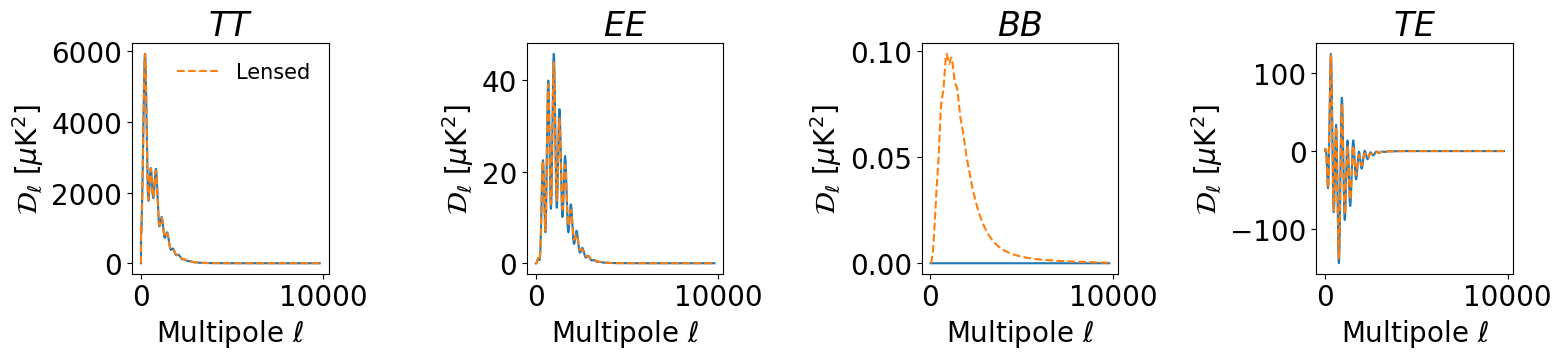

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for u, (ax, label) in enumerate(zip(axes,
                                   [r'$TT$', r'$EE$', r'$BB$', r'$TE$'])):
    ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells[:, u+1])
    ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells_lensed[:, u+1], ls='--', label='Lensed')
    ax.set_ylabel(rf'$\mathcal{{D}}_\ell$ [$\mu$K$^2$]')
    ax.set_title(label)
    ax.set_xlabel(r'Multipole $\ell$')
axes[0].legend(frameon=False)
fig.tight_layout()

In [18]:
# tau power spectrum
# tau_file = 'data/ref_tau.txt'
# if os.path.exists(tau_file):
#     tau_ps = np.loadtxt(tau_file, unpack=True)[1:].T
#     ells = np.loadtxt(tau_file, unpack=True)[0]
#     interp_tau = interp1d(ells, tau_ps[:, 0]/ells/(ells+1)*2.*np.pi, fill_value=0, bounds_error=False)
#     tau_ps = interp_tau(np.arange(lmax_sky+1))
# else:
tau_ps = np.sum(preion_model.get_tau(ells=ell, signal='both', Dells=False), axis=1)
#     np.savetxt(tau_file, np.c_[ells, tau_ps], header='ells, Dells tautau')

In [19]:
ell.max(), lmax_sky, tau_ps.shape

(9799, 9800, (9799,))

**Note:** In our notebook we will use the same spectra to generate the simulations and to make the analysis, but in practice they could be different as we dont know the real spectra of the observed CMB. 
In a standard analysis we correct for this mismatch at a later stage by debiasing the reconstructed lensing power spectrum.
In our idealized simulation case we won't need that.

In [20]:
# Simulate alms from Cls
alms_arr = hp.synalm(
    CMB_Cells[:, 1:].T,
    new=True, lmax=lmax_sky
)
alms_tau = hp.synalm(tau_ps, lmax=lmax_sky)
# tau_map = hp.synfast(interp_tau(hp_ls), nside=2048, ) #mK
alms = {'t':alms_arr[0], 'e':alms_arr[1], 'b':alms_arr[2], 'tau':alms_tau}

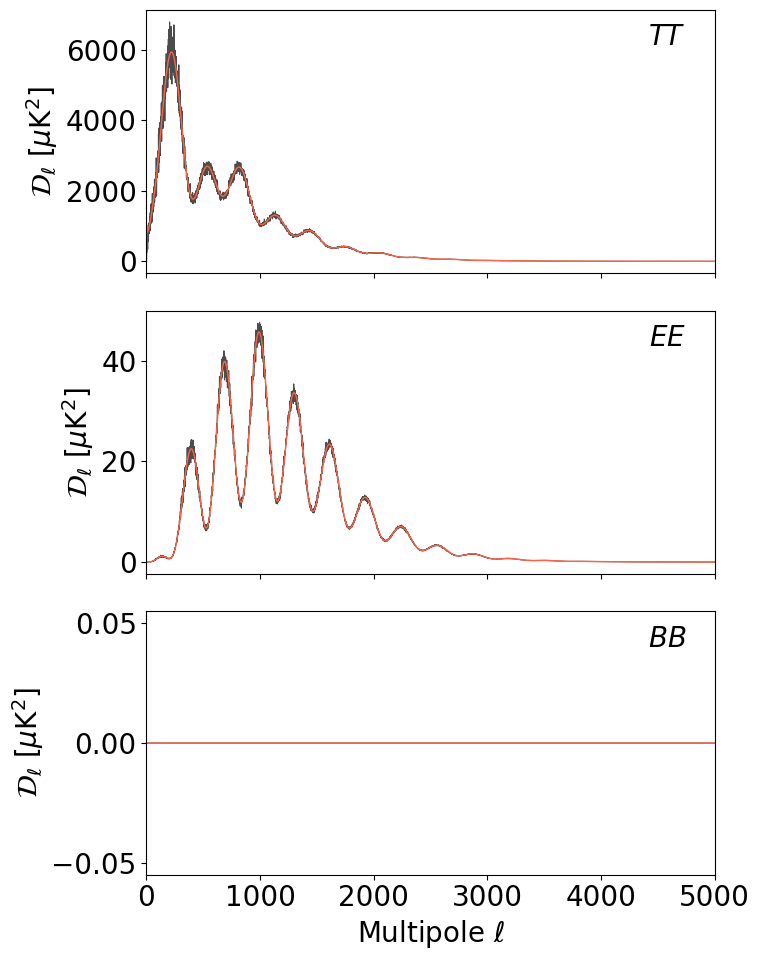

In [21]:
# Check if simulation has expected power spectrum
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
for u, (ax, key, label) in enumerate(zip(axes, ['t', 'e', 'b'],
                                   [r'$TT$', r'$EE$', r'$BB$'])):
    ax.plot(np.arange(lmax_sky+1), hp.alm2cl(alms[key])*f(np.arange(lmax_sky+1)), color='k', lw=.8, alpha=.7)
    ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells[:, u+1], color='tomato', lw=1.)
#     ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells_lensed[:, u+1], ls='--', label='Lensed')
    ax.text(.95, .95, label, transform=ax.transAxes, ha='right', va='top')
    ax.set_ylabel(rf'$\mathcal{{D}}_\ell$ [$\mu$K$^2$]')
axes[-1].set_xlabel(r'Multipole $\ell$')
axes[0].set_xlim(0, 5000)
# axes[1].set_ylim(0, 0.1)
fig.tight_layout()

In [22]:
hp.alm2cl(alms['tau']).shape, ell.shape

((9801,), (9799,))

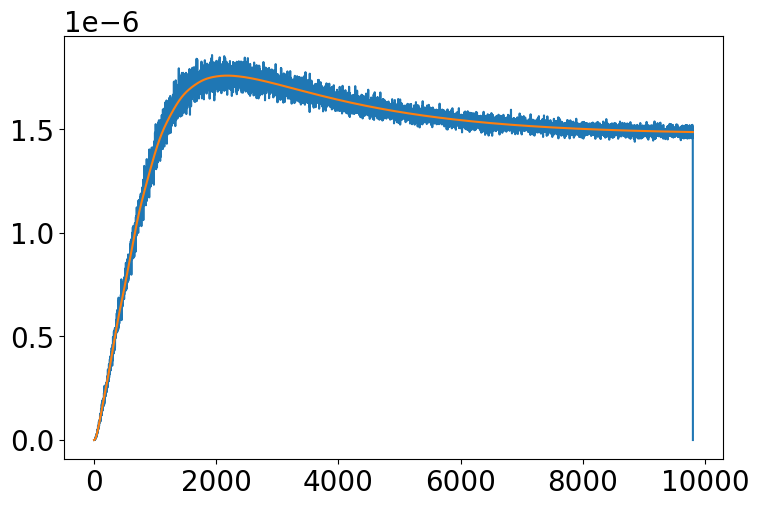

In [23]:
plt.plot(np.arange(lmax_sky+1), hp.alm2cl(alms['tau'])*f(np.arange(lmax_sky+1)))
plt.plot(ell, tau_ps*f(ell))

In [24]:
primary_t_map, primary_q_map, primary_u_map = hp.synfast(cls=CMB_Cells[:, 1:].T, nside=nside, pol=True, new=True)
primary_maps = {'t': primary_t_map, 'q': primary_q_map, 'u':primary_u_map}

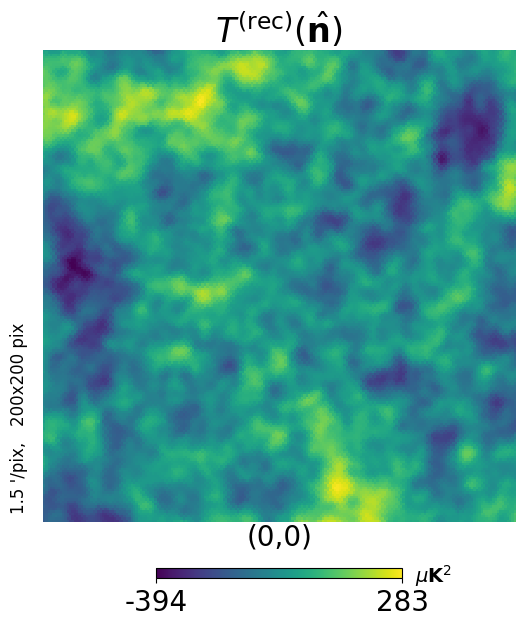

In [25]:
hp.gnomview(primary_t_map, title=r'$T^{(\mathrm{rec})}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

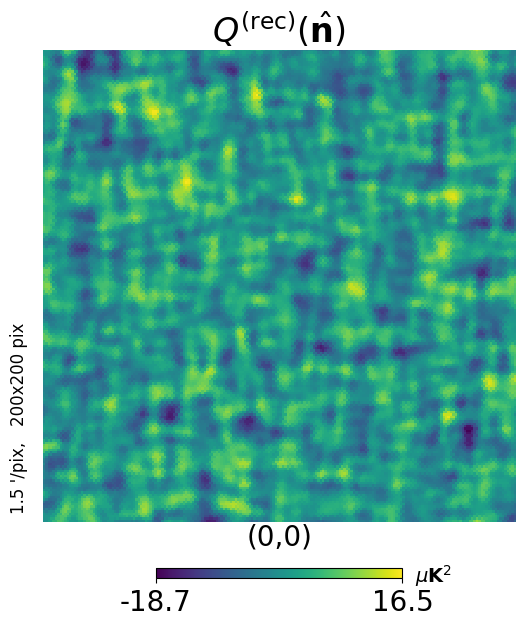

In [26]:
hp.gnomview(primary_q_map, title=r'$Q^{(\mathrm{rec})}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

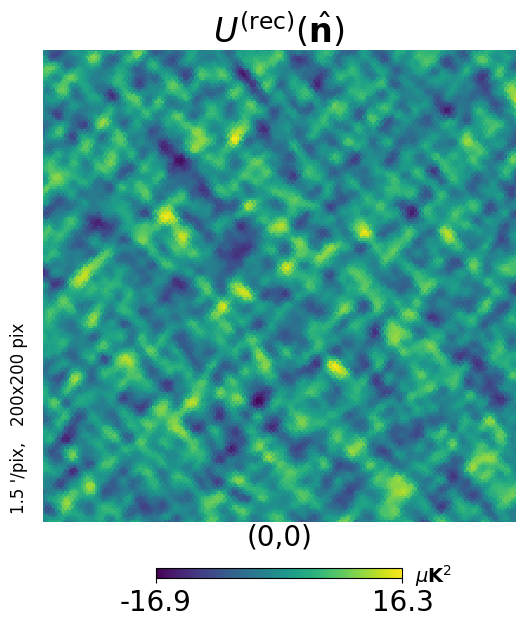

In [27]:
hp.gnomview(primary_u_map, title=r'$U^{(\mathrm{rec})}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

In [28]:
cls_temp = hp.anafast([primary_t_map, primary_q_map, primary_u_map], pol=True)
primary_cls_from_maps = {'tt': cls_temp[0], 'ee': cls_temp[1], 'bb':cls_temp[2]}

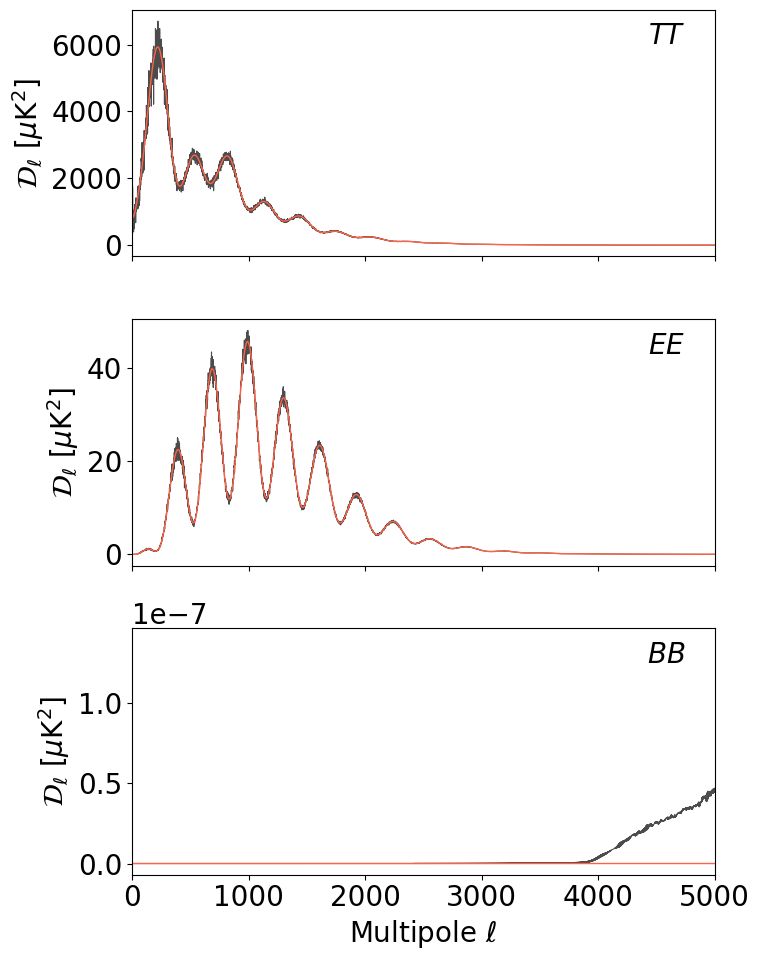

In [29]:
# Check if simulation has expected power spectrum
# ell = np.arange(lmax_sky+1)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
for u, (ax, key, label) in enumerate(zip(axes, ['tt', 'ee', 'bb'],
                                   [r'$TT$', r'$EE$', r'$BB$'])):
    ax.plot(np.arange(cls_temp[0].size), primary_cls_from_maps[key]*f(np.arange(cls_temp[0].size)), color='k', lw=.8, alpha=.7)
    ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells[:, u+1], color='tomato', lw=1.)
#     ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells_lensed[:, u+1], ls='--', label='Lensed')
    ax.text(.95, .95, label, transform=ax.transAxes, ha='right', va='top')
    ax.set_ylabel(rf'$\mathcal{{D}}_\ell$ [$\mu$K$^2$]')
axes[-1].set_xlabel(r'Multipole $\ell$')
axes[0].set_xlim(0, 5000)
# axes[1].set_ylim(0, 0.1)
fig.tight_layout()

# 3 - Add patchy screening to CMB maps

The patchy screening on the primary anisotropies can be written as 
\begin{equation}
\begin{aligned}
T(\hat{\mathbf{n}}) & =e^{-\tau(\hat{\mathbf{n}})} T^{(\mathrm{rec})}(\hat{\mathbf{n}}) \\
(Q \pm i U)(\hat{\mathbf{n}}) & =e^{-\tau(\hat{\mathbf{n}})}(Q \pm i U)^{(\mathrm{rec})}(\hat{\mathbf{n}}) \simeq(Q \pm i U)_0(\hat{\mathbf{n}})+\int \delta \tau(Q \pm i U)_1(\hat{\mathbf{n}}),
\end{aligned}
\end{equation}
where $T$ is the temperature fluctuation, and $Q$ and $U$ are the polarization Stokes parameters.

In [30]:
tau_global = preion_model.tau

In [31]:
# parameters which impact of the accuracy of the result (and the execution time):

lmax_out = 2048  # desired lmax of the lensed field.

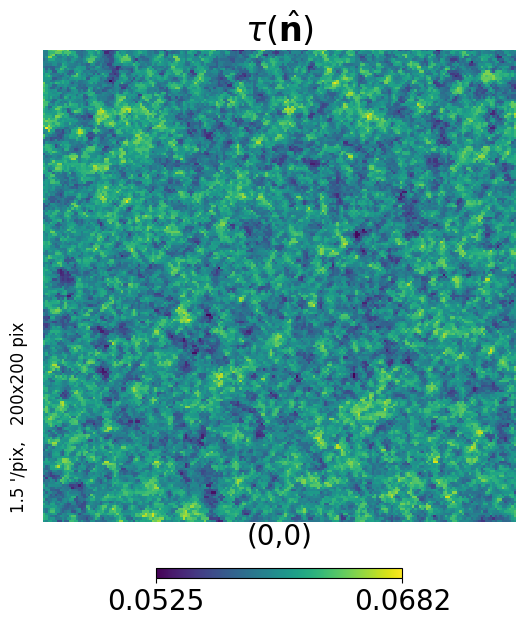

In [32]:
tau_map = hp.synfast(tau_ps, nside=nside, ) 
hp.gnomview(tau_map+tau_global, title=r'$\tau(\hat{\mathbf{n}})$')

In [33]:
# primary_temp_map = hp.synfast(CMB_Cells[:, 1], nside=nside, )
scattered_t_map = primary_t_map * np.exp(-tau_map)
scattered_q_map = primary_q_map * np.exp(-tau_map)
scattered_u_map = primary_u_map * np.exp(-tau_map)

scattered_maps = {'t': scattered_t_map, 'q': scattered_q_map, 'u': scattered_u_map}

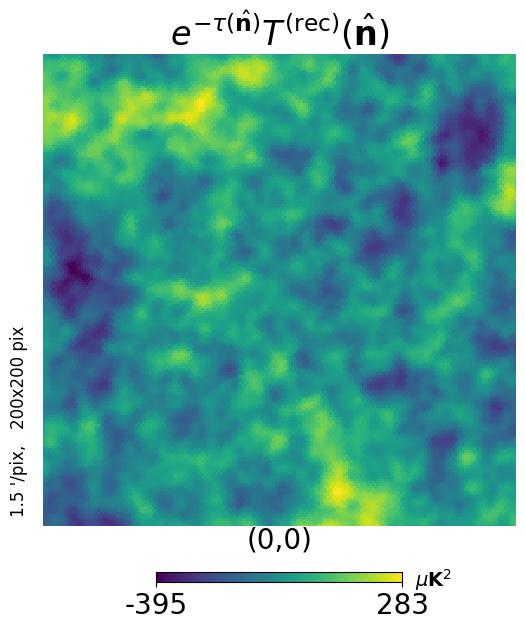

In [34]:
hp.gnomview(scattered_t_map, title=r'$e^{-\tau(\hat{\mathbf{n}})} T^{(\mathrm{rec})}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

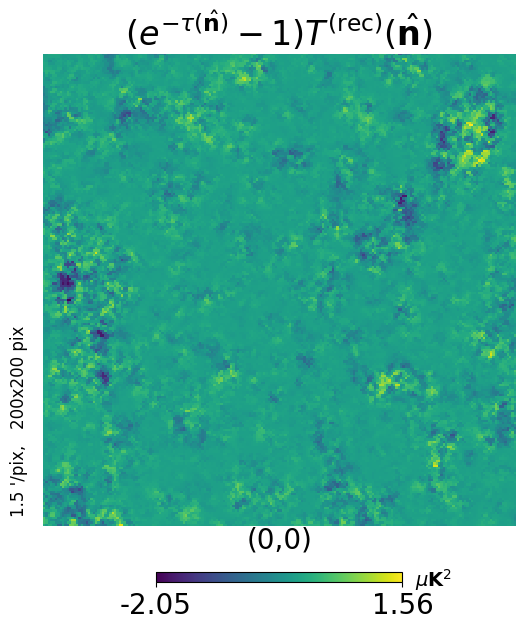

In [35]:
hp.gnomview(scattered_t_map-primary_t_map, title=r'$(e^{-\tau(\hat{\mathbf{n}})}-1) T^{(\mathrm{rec})}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

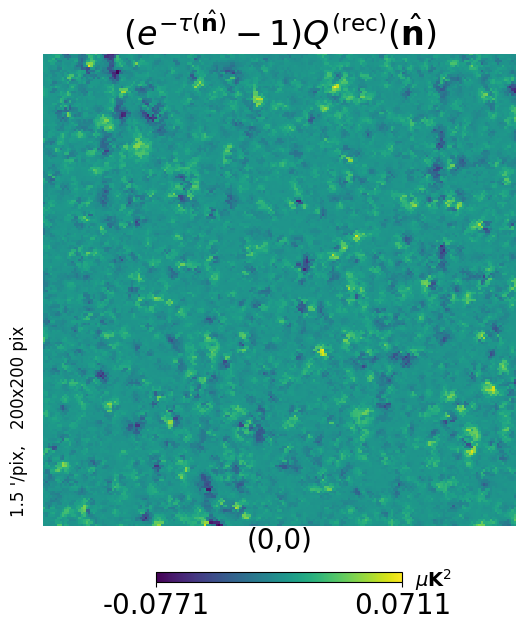

In [36]:
hp.gnomview(scattered_q_map-primary_q_map, title=r'$(e^{-\tau(\hat{\mathbf{n}})}-1) Q^{(\mathrm{rec})}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

# 4- Beam and noise


We now simulate observed CMB maps by convolving the lensed maps with a gaussian beam (resolution of our instrument) and adding a white noise.

In [37]:
from parameters import telescope_specs

In [38]:
tel = telescope_specs['CMB-S4-LAT']

In [39]:
nlev_t = tel['noise']  #Temperature noise level in muK.arcmin
nlev_p = nlev_t*np.sqrt(2.) #Polarisation noeise level in muK.arcmin (we wont use it here)

beam_fwhm_amin = tel['fwhm'] # Full width at half maximum of the gaussian beam of our instrument, in arcmin

lmax_ivf = int(tel['lmax'])
lmin_ivf = int(tel['lmin'])
ell_obs = np.arange(lmax_ivf+1)

print(lmax_ivf, lmin_ivf, lmax_sky)
# We will not the use the CMB modes outside of this interval
# IVF means inverse variance filter, this is an input of our quadratic estimator 


noise_t_lm = hp.synalm(np.ones(lmax_ivf+1)*(nlev_t*np.pi /180/60)**2)
noise_p_lm = hp.synalm(np.ones(lmax_ivf+1)*(nlev_p*np.pi /180/60)**2)
# Noise spectrum

cl_beam = hp.gauss_beam(fwhm=beam_fwhm_amin*np.pi/180/60, lmax=lmax_ivf)
# Gaussian beam 


tlm, elm, blm = hp.map2alm([scattered_t_map, scattered_q_map, scattered_u_map], iter=3, lmax=lmax_ivf, pol=True)
hp.almxfl(tlm, cl_beam, inplace=True)
hp.almxfl(elm, cl_beam, inplace=True)
hp.almxfl(blm, cl_beam, inplace=True)

# Convolution with the beam

tobs_lm = tlm + noise_t_lm
eobs_lm = elm + noise_p_lm
bobs_lm = blm + noise_p_lm
# This are our observed temperature and pol maps

8000 1000 9800


In [40]:
obs_t_map, obs_q_map, obs_u_map = hp.alm2map(alms=[tobs_lm, eobs_lm, bobs_lm], nside=nside, pol=True)
obs_maps = {'t': obs_t_map, 'q': obs_q_map, 'u':obs_u_map}

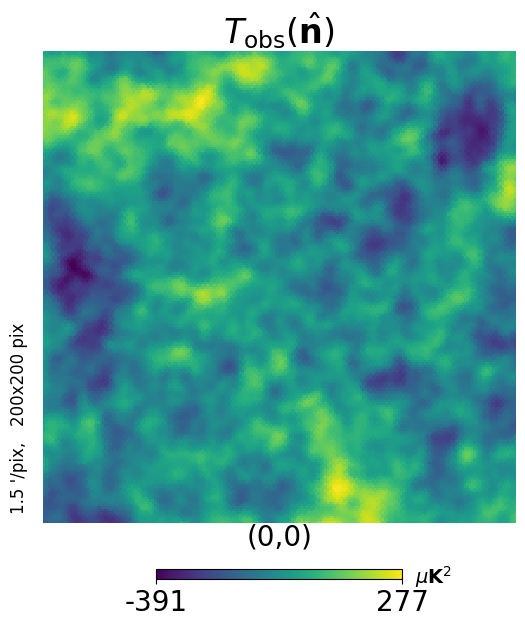

In [41]:
hp.gnomview(obs_maps['t'], title=r'$T_\mathrm{obs}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

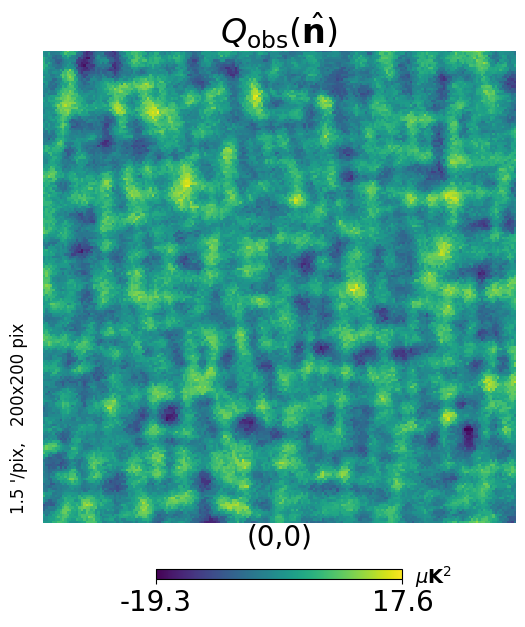

In [42]:
hp.gnomview(obs_maps['q'], title=r'$Q_\mathrm{obs}(\hat{\mathbf{n}})$', unit=r'$\mu$K$^2$')

In [43]:
out = hp.anafast([scattered_t_map, scattered_q_map, scattered_u_map], lmax=lmax_ivf, pol=True)
scattered_cls_from_maps = {'tt': out[0], 'ee': out[1], 'bb': out[2]}

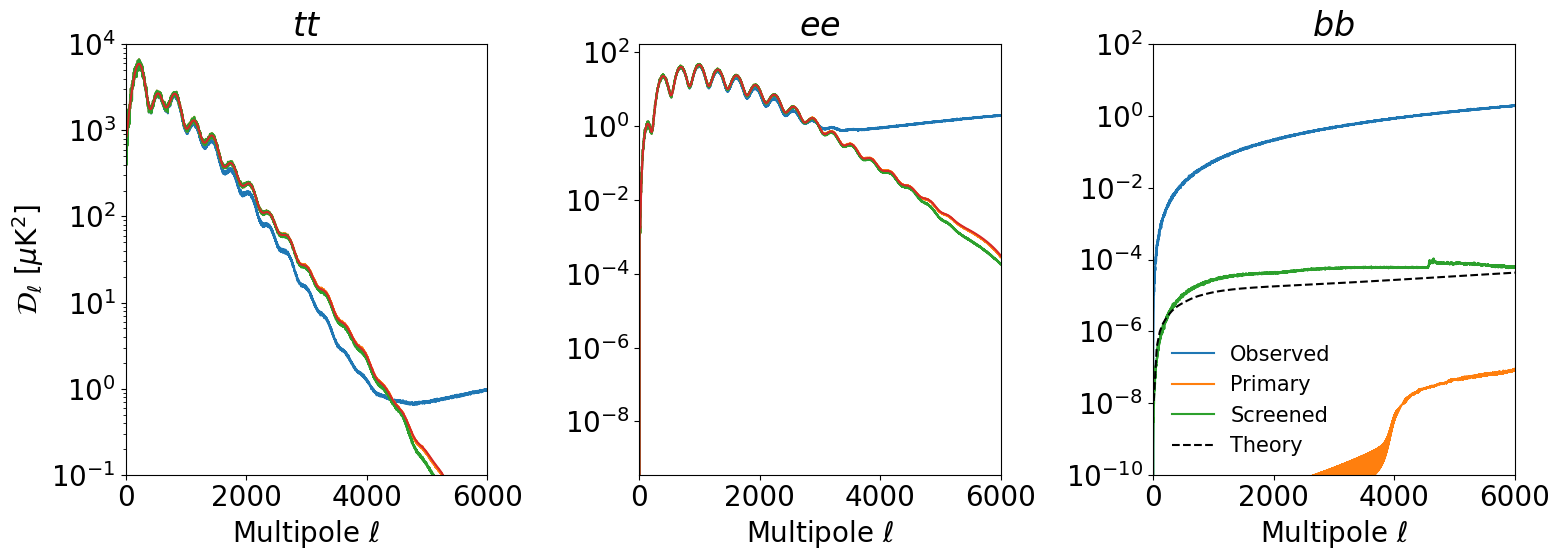

In [44]:
fig, axes = plt.subplots(1, 3, sharex=True, figsize=(16, 6))
axes[0].plot(ell_obs, hp.alm2cl(tobs_lm, lmax=lmax_ivf)*f(ell_obs), label='Observed')
axes[1].plot(ell_obs, hp.alm2cl(eobs_lm, lmax=lmax_ivf)*f(ell_obs), label='Observed')
axes[2].plot(ell_obs, hp.alm2cl(bobs_lm, lmax=lmax_ivf)*f(ell_obs), label='Observed')
for i, (ax, title) in enumerate(zip(axes, ['tt', 'ee', 'bb'])):
    ax.set_title(rf'${title}$')
    ax.set_xlabel(r'Multipole $\ell$')
    ax.semilogy(np.arange(primary_cls_from_maps[title].size), primary_cls_from_maps[title]*f(np.arange(primary_cls_from_maps[title].size)), label='Primary')
    ax.plot(ell_obs, scattered_cls_from_maps[title]*f(ell_obs), label='Screened')
    ax.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells[:, i+1])
axes[2].plot(ell_obs[10::50], preion_model.get_B_modes(ell_obs[10::50], Dells=True, Qrms=17.0), color='k', ls='--', label='Theory')
axes[0].set_ylabel(r'$\mathcal{D}_\ell$ [$\mu$K$^2$]')
axes[2].legend(frameon=False)
axes[0].set_ylim(0.1, 1e4)
axes[0].set_xlim(0, 6000)
axes[-1].set_ylim(1e-10, 100)
fig.tight_layout()

In [83]:
Qrms = 17.9
scattering_bb = preion_model.get_scattering_B_modes(ells=np.arange(1, 9800), signal='both', Dells=True, Qrms=Qrms)
screening_bb = preion_model.get_screening_B_modes(ells=np.arange(1, 9800), Dells=True)

In [46]:
Erms2 = np.sum(CMB_Cells[:, 2]*(2.*CMB_Cells[:, 0]+1.)/4./np.pi)
screening_bb_dvorkin_highl = 0.5 * Erms2 * tau_ps * np.exp(-2.*tau_global)  # l > 2000
screening_bb_dvorkin_lowl = np.exp(-2.*tau_global) / 2. * np.sum(CMB_Cells[:, 2]*tau_ps*(2.*CMB_Cells[:, 0]+1.)/4./np.pi)  # l < 300
# screening_bb_dvorkin_lowl = np.exp(-2.*tau_global) / 2. * np.trapz(CMB_Cells[:, 2]*tau_ps, CMB_Cells[:, 0]) /4./np.pi**2 # l < 300
scattering_bb_dvorkin = 3./100. * tau_ps * Qrms**2 * np.exp(-2.*tau_global)

In [ ]:
D_ells = (
    np.arange(1, 9800)[:, None]
    * (np.arange(1, 9800)[:, None] + 1)
    * screening_bb
    / 2.0
    / np.pi
    * (preion_model.T_cmb * 1e6) ** 2
)

In [47]:
np.sqrt(Erms2), Qrms

(6.547504366577638, 17.9)

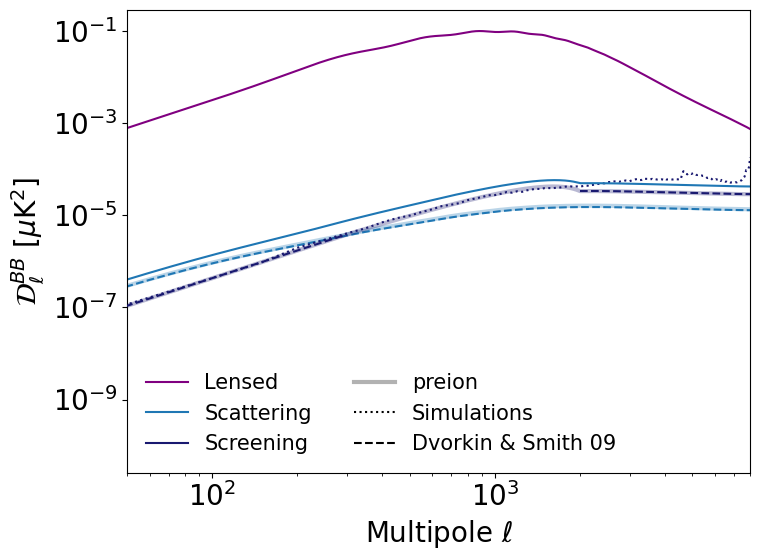

In [ ]:
plt.figure(figsize=(8, 6))
plt.loglog(np.arange(1, 9800), np.sum(scattering_bb, axis=1), color='C0', alpha=.3, lw=3.)
plt.plot(ell, scattering_bb_dvorkin*f(ell), color='C0', ls='--')
# plt.plot(ell_obs[10::50], scattering_bb[:, 1])
plt.plot(np.arange(1, 9800), screening_bb, color='midnightblue', alpha=.3, lw=3)
plt.plot(ell[ell>2000], screening_bb_dvorkin_highl[ell>2000]*f(ell[ell>2000]), color='midnightblue', ls='--')
plt.plot(ell[ell<300], screening_bb_dvorkin_lowl*f(ell[ell<300]), color='midnightblue', ls='--', zorder=10)

plt.plot(CMB_Cells_lensed[:, 0], CMB_Cells_lensed[:, 3]*f(CMB_Cells_lensed[:, 0]), color='purple', label='Lensed')
# plt.semilogy(np.arange(primary_cls_from_maps['bb'].size), primary_cls_from_maps['bb']*f(np.arange(primary_cls_from_maps['bb'].size)), label='Primary')
plt.plot(ell_obs[::50], scattered_cls_from_maps['bb'][::50]*f(ell_obs[::50]), color='midnightblue', ls=':')#alpha=.5)
# plt.plot(CMB_Cells[:, 0], f(CMB_Cells[:, 0])*CMB_Cells[:, 3])

plt.plot(np.arange(1, 9800), screening_bb+np.sum(scattering_bb, axis=1))

plt.plot([], [], ls='-', label='Scattering', color='C0')
plt.plot([], [], ls='-', label='Screening', color='midnightblue')

plt.plot([], [], color='k', ls='-', lw=3., alpha=.3, label='preion')
plt.plot([], [], color='k', ls=':', label='Simulations')
plt.plot([], [], color='k', ls='--', label='Dvorkin & Smith 09')

plt.legend(frameon=False, ncol=2)
# plt.ylim(1e-10, 100)
plt.xlim(50,8000)
plt.ylabel(r'$\mathcal{D}_\ell^{BB}$ [$\mu$K$^2$]')
plt.xlabel(r'Multipole $\ell$')
plt.tight_layout()
plt.savefig('bb_modes.pdf', dpi=220)

# 5 - Estimate the lensing potential field


Now that we have observed maps, we can define a QE to reconstruct the screning on this map.

Let X and Y be| two CMB maps that are screened with the same optical depth $\tau$. They can be either the temperature map T or the polarisation maps (Q and U).
The screening modulates the amplitude of both maps. This can be described by: 

\begin{equation}
<X(\boldsymbol{l}_1)Y(\boldsymbol{l}_2)>_{\mathrm{fixed} \, \tau} = f_{XY}(\boldsymbol{l}_1, \boldsymbol{l}_2) \tau(\boldsymbol{L})
\end{equation}
for $\boldsymbol{l}_1 \neq \boldsymbol{l}_2$ and  $\boldsymbol{L} = \boldsymbol{l}_1 + \boldsymbol{l}_2$. This $f_{XY}$ function describes the coupling between the different scales created by the screening. 

For polarisation only, in the case of the $EB$ cross spectrum which gives the highest signal to noise for patchy reionisation, it is given by (see e.g. Dvorking & Smith 2009)
\begin{equation}
f_{EB}^\tau(\boldsymbol{l}_1, \boldsymbol{l}_2) =  \left(\bar{C}_{\ell_1}^{E E}-\bar{C}_{\ell_2}^{B B}\right) \sin 2\left(\phi_{\ell_1}-\phi_{\ell_2}\right)
\end{equation}
where the $\bar{C}_{l}^{EE}$ and $\bar{C}_l^{BB}$ are the CMB polarisation spectra that include the patchy reionsation contribution.


In practice we only have one realization of the CMB, so we cannot average over it like in Eq. 1 to get the value of $\tau$. The best we can do is to define an estimator of $\tau$, and we will make sure it is be unbiased and has minimum variance.
We can define a generic estimator of $\tau$ by combining two maps (hence _quadratic_ estimator)
\begin{equation}
\hat \tau_{XY}(\boldsymbol{L}) = \frac{1}{R_{XY}(\boldsymbol{L})} \int_{\boldsymbol{L}=\boldsymbol{l}_1 + \boldsymbol{l}_2} \bar{X}_{\boldsymbol{l}_1} \bar{Y}_{\boldsymbol{l}_2} W_{XY}(\boldsymbol{l}_1, \boldsymbol{l}_2) \;
\end{equation}
with $\bar{X}$ and $\bar{Y}$ the inverse variance filtered CMB fields, $W_{XY}$ the weight of the estimator (also called the filter $F_{XY}^\tau$) and $R_{XY}(\boldsymbol{L})$ the normalization which makes the estimator unbiased, i.e. $<\hat \tau_{XY}>_{\mathrm{fixed} \, \tau} = \tau$. In practice, in the $EB$ case, the optimal form of the filter is given by
\begin{equation}
W_{E B}^\tau\left(\boldsymbol{l}_1, \boldsymbol{l}_2\right) = F_{E B}^\tau\left(\boldsymbol{l}_1, \boldsymbol{l}_2\right)=\frac{f_{E B}^\tau\left(\boldsymbol{l}_1, \boldsymbol{l}_2\right)}{\left(C_{l_1}^{E E}+N_{l_1}^{E E}\right)\left(C_{l_2}^{B B}+N_{l_2}^{B B}\right)},
\end{equation}
in order to minimise the variance and to reduce the expectation value of the $\tau$ estimator to
\begin{equation}
\left\langle\widehat{\tau}_{E B}\left(\vec{\ell}_1\right) \widehat{\tau}_{E B}\left(\vec{\ell}_2\right)\right\rangle=(2 \pi)^2 \delta\left(\vec{\ell}_1, \vec{\ell}_2\right)\left[C_L^{\tau \tau}+\tilde{N}_{E B}^\tau(\vec{L})\right].
\end{equation}

The inverse variance filtered maps are given by 
\begin{equation}
\bar{X}_{\boldsymbol{l}} = \frac{X_{\boldsymbol{l}}}{C_l^{XX} + N_l^{XX}} = X_{\boldsymbol{l}}\times\mathrm{ftl}(l)
\end{equation}
with $  N_l^{XX}$ the noise spectrum of the map.

Using the Eq. 1, Hu and Okamoto 2002 introduced an unbiased and minimum variance estimator with $W_{XY} = f_{XY}$ and the reponse
\begin{equation}
R_{XY}(\boldsymbol{L}) = \int \frac{d^2 \vec{\ell}_1}{(2 \pi)^2} f_{E B}^\tau\left(\vec{\ell}_1, \vec{\ell}_2\right) F_{E B}^\tau\left(\vec{\ell}_1, \vec{\ell}_2\right),
\end{equation}
and the zeroth order bias for $\tau$ reconstruction is defined as $\tilde{N}^\tau_{EB}(\boldsymbol{L}) \equiv R_{EB}(\boldsymbol{L})^{-1}$.

**Note:** I have summarized here the QE in the flat sky approximation, where we identify spherical harmonics with Fourier modes. The curved sky equations (introduced in Okamoto and Hu 2003) are similar but a bit more complex. The **plancklens** module implements the curved sky QE (see Planck 2018 results VIII for the actual implementation).


Let us now implement the $EB$ estimator using the **plancklens** package. 

We start by defining the inverse variance filter of the temperature map.



In [ ]:
cl_transf = cl_beam 
# The transfer function of our maps is the beam of the instrument
# In some configurations we should also take into account the pixel window function (given by hp.pixwin(nside_lens)), but we do not need it here 
# (in our simulations the pixel value is the value at the center of the pixel and not the average of the CMB inside the pixel).

ftl = {}
ftl['b'] = utils.cli(CMB_Cells[:, 3][:lmax_ivf + 1] + (nlev_p / 60. / 180. * np.pi / cl_transf) ** 2)
ftl['b'][:lmin_ivf] *= 0.
ftl['e'] = utils.cli(CMB_Cells[:, 2][:lmax_ivf + 1] + (nlev_p / 60. / 180. * np.pi / cl_transf) ** 2)
ftl['e'][:lmin_ivf] *= 0.
ftl['t'] = utils.cli(CMB_Cells[:, 1][:lmax_ivf + 1] + (nlev_t / 60. / 180. * np.pi / cl_transf) ** 2)
ftl['t'][:lmin_ivf] *= 0.
# This is the inverse variance filter
# It also sets the minimum and maximum scales of the CMB maps used in the reconstruction 


def get_alm_ivfs(x):
    """The eval_qe function of plancklens ask for a callable to access the filtered CMB maps"""
    if x =='t':
        return hp.almxfl(tobs_lm, ftl[x]* utils.cli(cl_transf[:lmax_ivf+1]))
    elif x == 'e':
        return hp.almxfl(eobs_lm, ftl[x]* utils.cli(cl_transf[:lmax_ivf+1]))
    elif x == 'b':
        return hp.almxfl(bobs_lm, ftl[x]* utils.cli(cl_transf[:lmax_ivf+1]))
    else:
        return 0

We now define our estimator. 
The cls_weight below are the Cls that are used in the weight $W_{XY}$ of the estimator.

In [41]:
# We want to reconstruct the lensing potential field up to this lmax
lmax_qlm = lmax_ivf#2048

In [54]:
out = hp.alm2cl([tobs_lm, eobs_lm, bobs_lm], lmax=lmax_ivf)
cls_weight = {}
for i, key in enumerate(['tt', 'ee', 'bb', 'be']):
    cls_weight[key] = out[i]

dict_keys(['tt', 'ee', 'bb', 'te'])


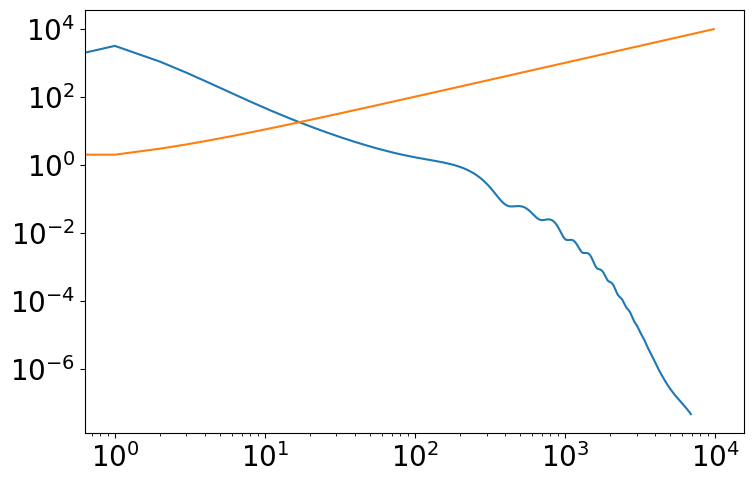

In [ ]:
# cls_path = opj(os.path.dirname(os.path.abspath(plancklens.__file__)), 'data', 'cls')
# cls_weight = utils.camb_clfile(os.path.join(cls_path, 'FFP10_wdipole_lensedCls.dat'))
# plt.loglog(cls_weight['tt'])
# plt.plot(CMB_Cells[:, 0])

The function below performs the quadratic estimation. 
The glm and the clm are respectively the gradient and the curl modes of the defelection field. 
In current CMB surveys, the curl modes are unobservable so they are often used as a consistency check. In our simulation they should be zero.

In **plancklens**, the estimator key tells which field we want to reconstruct and which combination of maps we want. 
Here we will use the 'ptt' key, the first p means we want to reconstruct $\phi$, and the 'tt' means we are using the temperature maps on both legs of the estimator. 

The function qest.eval_qe will solve for the inrtgral defined in teh Eq. 3 of the cell above, without the normalisation $R_{XY}$. In practice **plancklens** works in pixel space: the convolution of Eq. 3 in Fourier space becomes a product of filtered maps in real space.


In [55]:
key = 'f_eb'

fn_glm = 'glm'
fn_clm = 'clm'

if not cacher.is_cached(fn_glm) or not cacher.is_cached(fn_clm):
    glm, clm = qest.eval_qe(key, lmax_ivf, cls_weight, get_alm_ivfs, nside=2048, lmax_qlm=lmax_qlm, verbose=True)
    cacher.cache(fn_glm, glm)
    cacher.cache(fn_clm, clm)
glm = cacher.load(fn_glm)
clm = cacher.load(fn_clm)


The functions below define the the response $R_{XY}$ of the estimator, which is used to normalise $\hat \phi$

In [61]:
#---- QE response calculation library:
qresp_dd = qresp.resp_lib_simple(os.path.join(TEMP, 'qresp'), lmax_ivf, cls_scattered, cls_primary,
                                 ftl, lmax_qlm)

# Lensing response according to the fiducial cosmology:
resp = qresp_dd.get_response(key, 'p')


# Estimator normalization is the inverse response:
qnorm = utils.cli(resp)                               

CHECKING HASHFILE plens_write/lensing_tutorial/qresp/resp_hash.pk
ERROR: HASHCHECK FAIL AT KEY clscmb bb
   UNEQUAL VALUES
    V1 =  0e94113a61737d3b7e204c40000a94a4d5a46ddf
    V2 =  23b2d26590be7d5ded9f34a1a04e04103eed06b0
dict_keys(['lmaxqe', 'lmax_qlm', 'clsweight tt', 'clsweight ee', 'clsweight bb', 'clsweight te', 'clscmb tt', 'clscmb ee', 'clscmb bb', 'clscmb te', 'falt'])
dict_keys(['lmaxqe', 'lmax_qlm', 'clsweight tt', 'clsweight ee', 'clsweight bb', 'clsweight te', 'clscmb tt', 'clscmb ee', 'clscmb bb', 'clscmb te', 'falb', 'fale', 'falt'])


AssertionError: 

Let us now compare our estimated $\hat \phi$ with the input $\phi$ of our simulation !

In [24]:
plm_input = utils.alm_copy(alms['p'], lmax=lmax_qlm)

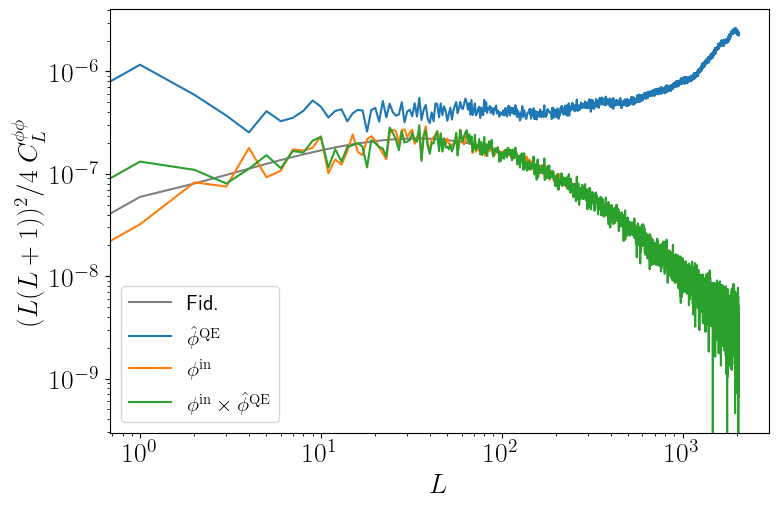

In [25]:
ell = np.arange(2049)

plt.plot(ell, pp2kk(ell) * cl_unl['pp'][ell], label='Fid.', c='grey')

plt.plot(ell, pp2kk(ell) * hp.alm2cl(glm)[ell]  * qnorm[ell] ** 2, label='$\hat \phi^\mathrm{QE}$')


plt.plot(ell, pp2kk(ell) * hp.alm2cl(plm_input)[ell], label='$\phi^\mathrm{in}$')


plt.plot(ell, pp2kk(ell) * hp.alm2cl(glm, plm_input)[ell] *qnorm[ell], label='$\phi^\mathrm{in} \\times \hat \phi^\mathrm{QE}$')

plt.loglog()


plt.xlabel(r'$L$')
plt.ylabel(r'$ (L(L+1))^2/ 4 \; C_L^{\phi \phi} $') 

plt.legend()

What do we see here ? Is the blue curve the spectrum we expect ? Why is it so bad ?

# 6 - Debiasing the QE spectrum 

As you can see above, the auto spectrum of the $\hat \phi$ seems to be totally biased. This is due to the fact that the QE will take all correlations between different CMB scales as due to lensing. In the CMB there are random correlations between different scales, and the QE will think they are due to lensing.
This is known as the $N_L^{(0)}$ bias, and it can be estimated analytically. When the weights used in the estimator are the same as the CMB response, then we have $N_L^{(0)} = 1/R_L$.

We use plancklens to get an estimate of this $N_L^{(0)}$.


In [26]:
N0s =  nhl.get_nhl(key, key, cls_weight, {'tt':ftl}, lmax_ivf, lmax_ivf )

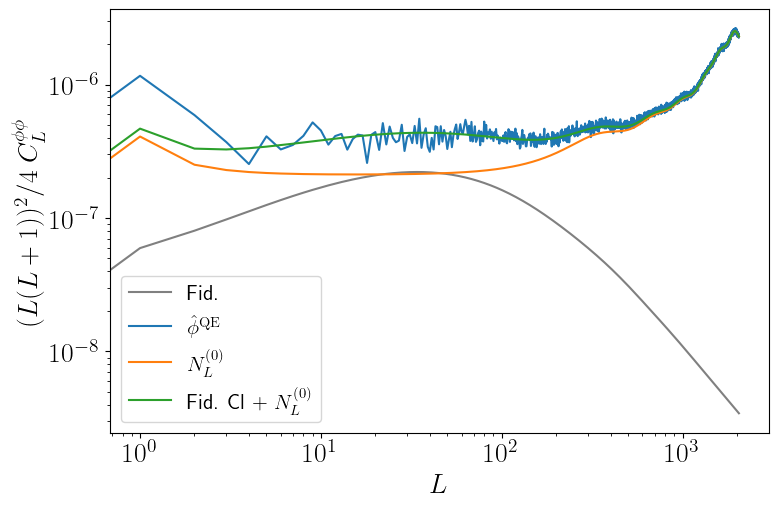

In [27]:

plt.plot(ell, pp2kk(ell) * cl_unl['pp'][ell], label='Fid.', c='grey')

plt.plot(ell, pp2kk(ell) * hp.alm2cl(glm)[ell]  * qnorm[ell] ** 2, label='$\hat \phi^\mathrm{QE}$')

plt.plot(ell, pp2kk(ell)*N0s[0][ell]* qnorm[ell] ** 2., label='$N_L^{(0)}$')


# plt.plot(ell, pp2kk(ell) * (hp.alm2cl(glm)[ell] -N0s[0][ell]) * qnorm[ell] ** 2, label='$\hat \phi^\mathrm{QE} - N_L^{(0)}$')

plt.plot(ell, pp2kk(ell) * (cl_unl['pp'][ell] + N0s[0][ell]* qnorm[ell] ** 2), label='Fid. Cl + $N_L^{(0)}$')


plt.loglog()


plt.xlabel(r'$L$')
plt.ylabel(r'$ (L(L+1))^2/ 4 \; C_L^{\phi \phi} $') 

plt.legend()

We now have an estimator of the lensing power spectrum which can be debiased. 

There are higher order bias terms, such as $N_L^{(1)}$ due to CMB correlations which are created by lensing, or $N_L^{(3/2)}$ which arise due to the non gaussianity of the LSS. 

To perform a realistic analysis we would have to take into account the mask of the survey. This creates also a signal in the QE which is called the mean field, it is the response of the QE to the mask. We can estimate it using simulations of the experiment, and subtract it from our $\hat \phi$ estimate. 

All the ingredients we put in the lensing reconstruction are fiducial ones: in practice we don't know exactly the CMB spectra, nor the beam or the noise level of our instrument. 
This is taken into account in a realization dependent debiaser. 

# 7 - Realization dependent debiaser 

Let's use the same simulation with the same input spectra, but reconstruct the lensing potential with a QE using biased fiducial ingredients.

Using the biased ingredients to estimate the N0 bias will get us a biased estimate of the power spectrum. 
But we can use a semi-analytical realization dependent debiaser. This combines the observed spectra of teh data map with the assumed fiducial spectra. We can show that this debiaser is robust in the mismatch between the data and the fiducial assumptions.

We will assume that the CMB Cls are 10 % lower than the true Cls.
This would be a huge mismatch because CMB Cls are known at much better than 10%.


In [28]:
bias = 0.9

cl_biased = {}
for k in ['tt', 'te', 'ee']:
    cl_biased[k] = copy.deepcopy(cl_len[k]) * bias


ftl_b = utils.cli(cl_biased['tt'][:lmax_ivf + 1] + (nlev_t / 60. / 180. * np.pi / cl_transf) ** 2)
ftl_b[:lmin_ivf] *= 0.
# This is the inverse variance filter
# It also sets the minimum and maximum scales of the CMB maps used in the reconstruction 


def get_alm_ivfs_b(x):
    """The eval_qe function of plancklens ask for a callable to access the filtered CMB maps"""
    if x =='t':
        return hp.almxfl(tobs_lm, ftl_b* utils.cli(cl_transf[:lmax_ivf+1]))
    else:
        return 0


glm_b, _ = qest.eval_qe(key, lmax_ivf, cl_biased, get_alm_ivfs_b, nside=2048, lmax_qlm=lmax_qlm, verbose=True)


QE 1 out of 1 :
in-spins 1st leg and out-spin [0] 0
in-spins 2nd leg and out-spin [0] 1


In [29]:
#---- QE response calculation library:
qresp_dd_b = qresp.resp_lib_simple(os.path.join(TEMP, 'qresp_b' +str(bias)), lmax_ivf, cl_biased, cl_biased,
                                 {'t': ftl_b}, lmax_qlm)

# Lensing response according to the fiducial cosmology:t
resp_b = qresp_dd_b.get_response(key, 'p')


# Estimator normalization is the inverse response:
qnorm_b = utils.cli(resp_b)  

In [30]:
N0s_b =  nhl.get_nhl(key, key, cl_biased, {'tt':ftl_b}, lmax_ivf, lmax_ivf )

# We use a semi analytical RD-N0 debiaser, using the IVF data spectrum in the N0 estimate 
RDN0s_b =  nhl.get_nhl(key, key, cl_biased, {'tt': hp.alm2cl(get_alm_ivfs_b('t'))}, lmax_ivf, lmax_ivf )

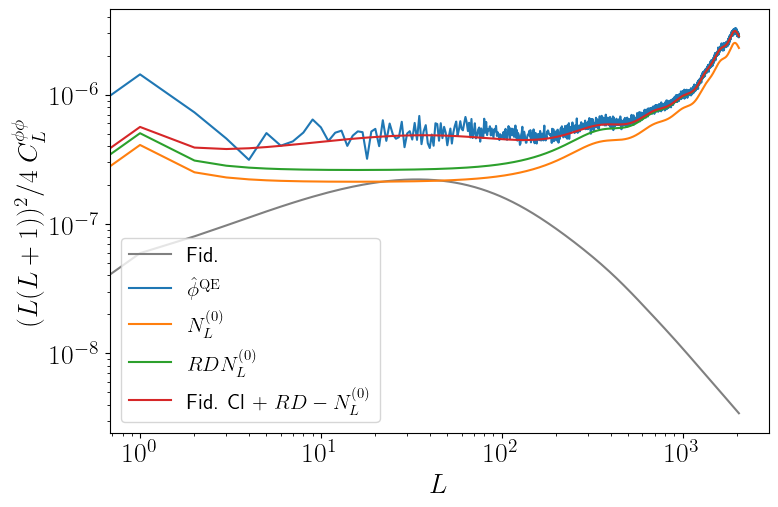

In [31]:

plt.plot(ell, pp2kk(ell) * cl_unl['pp'][ell], label='Fid.', c='grey')

plt.plot(ell, pp2kk(ell) * hp.alm2cl(glm_b)[ell]  * qnorm_b[ell] ** 2, label='$\hat \phi^\mathrm{QE}$')

plt.plot(ell, pp2kk(ell)*N0s[0][ell]* qnorm_b[ell] ** 2., label='$N_L^{(0)}$')
plt.plot(ell, pp2kk(ell)*RDN0s_b[0][ell]* qnorm_b[ell]**2, label='$RDN_L^{(0)}$')


plt.plot(ell, pp2kk(ell) * (cl_unl['pp'][ell] + RDN0s_b[0][ell]* qnorm_b[ell] ** 2), label='Fid. Cl + $RD-N_L^{(0)}$')


plt.loglog()


plt.xlabel(r'$L$')
plt.ylabel(r'$ (L(L+1))^2/ 4 \; C_L^{\phi \phi} $') 

plt.legend()

The orange curve above gives a biased estimate of the N0, because the Cls we feed him are not the ones of the CMB maps. Using the semi-analytical RD-N0 (red curve), it seems there that we can recover an unbiased estimate of the CMB power spectrum.